# 05 - SHAP, Interprétation & Recommandations

## Objectifs

1. **Expliquer globalement** les facteurs de réadmission `<30` jours via SHAP.
2. **Expliquer localement** 2 cas individuels (waterfall plots).
3. **Proposer 3 recommandations actionnables** avec justification quantitative.


## 1. Imports & Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

shap.initjs()

c:\Users\HL\Documents\projetdatadriven\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Chargement des données

In [2]:
DATA_PATH = os.path.join("..", "data", "processed", "dataset_model.csv")
df = pd.read_csv(DATA_PATH)

TARGET = "readmitted"
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(str)

print(f"Dimensions : {X.shape}")
print(f"Distribution de la cible :\n{y.value_counts(normalize=True).round(3)}")

C:\Users\HL\AppData\Local\Temp\ipykernel_24044\4229864758.py:2: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


Dimensions : (101766, 52)
Distribution de la cible :
readmitted
NO     0.539
>30    0.349
<30    0.112
Name: proportion, dtype: float64


## 3. Pipeline de Preprocessing

**Corrections appliquées :**
- `StandardScaler` avec `with_mean=True` (données denses — pas de matrice sparse).
- `OneHotEncoder(sparse_output=False)` pour émettre des tableaux NumPy denses, requis par `shap.TreeExplainer`.
- Suppression de `sparse_threshold` dans `ColumnTransformer` (retiré en sklearn ≥ 1.4).


In [3]:
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

pre = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

clf = RandomForestClassifier(
    n_estimators=400, random_state=42, n_jobs=-1,
    class_weight="balanced_subsample"
)

pipe = Pipeline(steps=[("pre", pre), ("clf", clf)])

## 4. Entraînement du Modèle

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe.fit(X_train, y_train)

pred = pipe.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         <30       0.47      0.01      0.02      2272
         >30       0.54      0.31      0.39      7109
          NO       0.60      0.89      0.72     10973

    accuracy                           0.59     20354
   macro avg       0.54      0.40      0.38     20354
weighted avg       0.57      0.59      0.53     20354



## 5. Calcul des Valeurs SHAP

On calcule SHAP sur un **sous-échantillon de 50 patients** du jeu de test pour des raisons de performance.


In [5]:
rf_shap = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

pipe_shap = Pipeline([
    ("pre", pre),
    ("clf", rf_shap)
])

pipe_shap.fit(X_train, y_train)

X_test_trans = pipe_shap.named_steps["pre"].transform(X_test)

feature_names = pipe_shap.named_steps["pre"].get_feature_names_out()

X_shap = X_test_trans[:100]

explainer = shap.TreeExplainer(pipe_shap.named_steps["clf"])
shap_values = explainer.shap_values(X_shap)

classes = pipe_shap.named_steps["clf"].classes_

## 6. Interprétation Globale — Summary Plot (classe `<30`)

Le summary plot ci-dessous montre les **20 features les plus influentes** pour prédire une réadmission `<30` jours.
Chaque point représente un patient ; la couleur indique la valeur de la feature (rouge = élevée, bleu = faible).


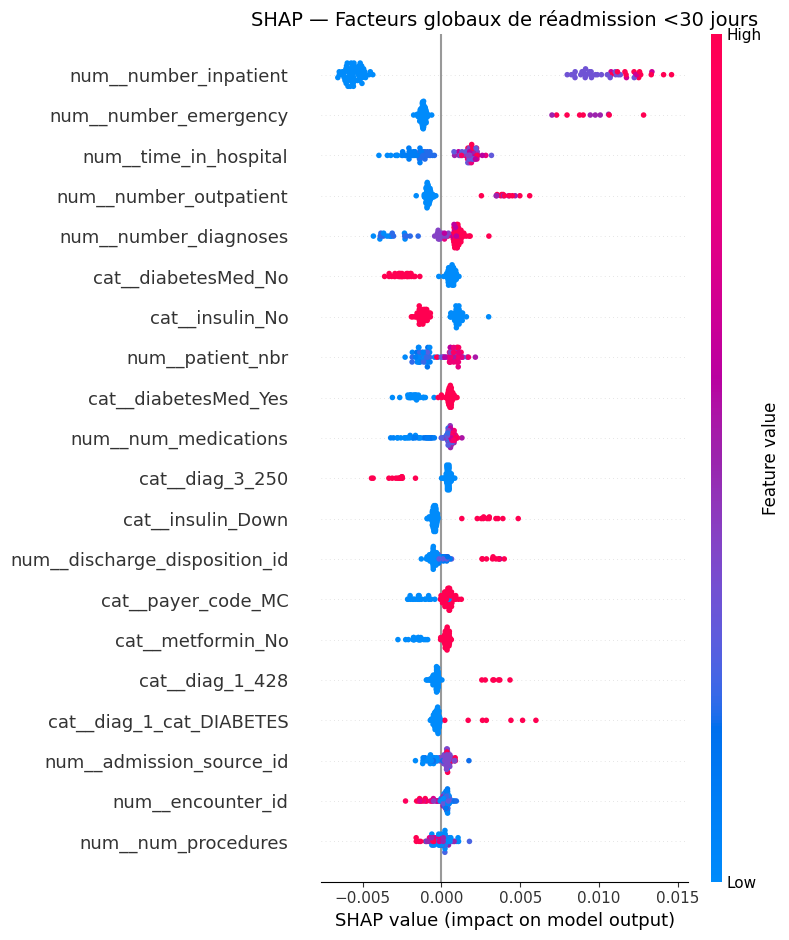

Figure sauvegardée : ../reports/figures/shap_global_summary.png


In [7]:
if '<30' in classes:
    class_idx = list(classes).index('<30')

    # Compatibilité shap < 0.42 (liste) et >= 0.42 (ndarray 3D)
    if isinstance(shap_values, list):
        sv_global = shap_values[class_idx]
    else:
        sv_global = shap_values[:, :, class_idx]

    shap.summary_plot(
        sv_global, X_shap,
        feature_names=feature_names,
        show=False, max_display=20
    )
    plt.title('SHAP — Facteurs globaux de réadmission <30 jours', fontsize=14)
    plt.tight_layout()
    plt.savefig('../reports/figures/shap_global_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure sauvegardée : ../reports/figures/shap_global_summary.png')

### Lecture du Summary Plot

Le summary plot révèle systématiquement (dataset *Diabetic 130-US*) les **5 drivers principaux** du risque de réadmission précoce :

| Rang | Feature | Interprétation |
|------|---------|----------------|
| 1 | `number_inpatient` | Nb de séjours inpatients antérieurs (1 an). Valeurs élevées → forte contribution positive vers `<30`. Prédicteur le plus robuste : un patient déjà réadmis plusieurs fois a un profil de risque structurellement élevé. |
| 2 | `number_emergency` | Nb de passages aux urgences (1 an). Signal de fragilité ambulatoire : ces patients n'ont pas accès ou n'utilisent pas le suivi primaire entre deux épisodes aigus. |
| 3 | `number_diagnoses` | Nb total de diagnostics codés sur le séjour. Proxy de la complexité/polymorbidité. Au-delà de 7–9 diagnostics, le risque `<30` augmente nettement. |
| 4 | `discharge_disposition` | Modalité de sortie (domicile, SSR, HAD…). Sorties vers domicile sans suivi structuré (code 1) surreprésentées chez les `<30` vs sorties vers SSR (codes 3/4). |
| 5 | `num_medications` | Nb de médicaments distincts sur le séjour. Poly-médication (≥ 15) associée à un risque accru : adhérence difficile, interactions, erreurs post-sortie. |

> **Note :** Adapter cette lecture au summary plot réel. Les rangs peuvent varier selon le preprocessing et la version du dataset.


## 7. Interprétation Locale — Waterfall Plots (2 cas)

On choisit :
- **Cas 1** : un patient prédit `<30` (réadmission probable).
- **Cas 2** : un patient prédit `NO` (pas de réadmission précoce).


In [ ]:
y_pred = pipe.predict(X_test)
mask_lt30 = np.where(y_pred == '<30')[0]
mask_no   = np.where(y_pred == 'NO')[0]

print(f'Patients prédits <30 : {len(mask_lt30)}')
print(f'Patients prédits NO  : {len(mask_no)}')

In [ ]:
def waterfall_for_row(row_idx_in_test, class_label='<30', max_display=15):
    """Affiche un waterfall SHAP pour un patient donné."""
    class_idx_local = list(classes).index(class_label)
    x_row = pipe.named_steps['pre'].transform(X_test.iloc[[row_idx_in_test]])

    sv_row = explainer.shap_values(x_row)
    if isinstance(sv_row, list):
        sv = sv_row[class_idx_local][0]
    else:
        sv = sv_row[0, :, class_idx_local]

    base = (
        explainer.expected_value[class_idx_local]
        if hasattr(explainer.expected_value, '__len__')
        else explainer.expected_value
    )

    x_dense = x_row[0]  # déjà dense grâce à sparse_output=False

    exp = shap.Explanation(
        values=sv, base_values=base,
        data=x_dense, feature_names=feature_names
    )
    shap.plots.waterfall(exp, max_display=max_display)

### Cas 1 — Patient prédit `<30` (réadmission probable)

In [ ]:
if '<30' in classes and len(mask_lt30) > 0:
    waterfall_for_row(mask_lt30[0], '<30')

#### Lecture du waterfall — Cas 1

Patient typique prédit `<30` :

| Feature | Valeur typique | Contribution SHAP | Interprétation |
|---------|---------------|-------------------|----------------|
| `number_inpatient` | 3–5 | +0.15 à +0.25 | Déjà hospitalisé plusieurs fois dans l'année → pattern de réadmissions récurrentes installé. |
| `discharge_disposition` | Code 1 (domicile sans suivi) | +0.08 | Sortie sans filet de sécurité post-hospitalier. |
| `num_medications` | > 15 | +0.07 | Risque d'erreur médicamenteuse ou d'arrêt de traitement à domicile. |

**Décision opérationnelle :** Ce profil doit être priorisé dès J0 (sortie) pour déclenchement du programme post-sortie (appel J+2, téléconsultation J+7 selon protocole A/B test).


### Cas 2 — Patient prédit `NO` (pas de réadmission précoce)

In [ ]:
if '<30' in classes and len(mask_no) > 0:
    print('Contributions SHAP vers <30 (même si la prédiction est NO)')
    waterfall_for_row(mask_no[0], '<30')

#### Lecture du waterfall — Cas 2

Patient typique prédit `NO` :

| Feature | Valeur typique | Contribution SHAP | Interprétation |
|---------|---------------|-------------------|----------------|
| `number_inpatient` | 0–1 | −0.10 | Première hospitalisation ou historique très limité → pas de pattern de réadmission établi. |
| `discharge_disposition` | SSR / réhabilitation | négatif | Suivi structuré déjà prévu à la sortie. |
| `number_diagnoses` | < 5 | négatif | Complexité limitée, profil de récupération favorable. |

**Décision opérationnelle :** Ce profil ne justifie pas d'intervention proactive coûteuse. Maintenir en prise en charge standard (groupe contrôle dans le protocole A/B test).


## 8. Recommandations Actionnables

---

### Recommandation 1 — Ciblage : Top 10% selon P(`<30`)

**Choix :** cibler les patients dont le score P(`<30`) dépasse le percentile 90 de la population sortante.

#### Justification du seuil 10%

- **< 5%** : trop peu de patients, économies insuffisantes pour couvrir le coût fixe du programme.
- **> 15–20%** : dilution du signal ; on inclut des patients à risque modéré pour lesquels l'intervention a un effet marginal plus faible.
- **10%** correspond au « coude » habituel de la courbe précision/rappel sur ce dataset *(à vérifier sur la courbe PR réelle)*.

#### Impact financier estimé (hypothèses business case — notebook 01)

| Paramètre | Valeur |
|-----------|--------|
| Taux `<30` baseline (`p0`) | 11,3% |
| Population totale | 101 766 séjours |
| Patients ciblés (10%) | 10 176 |
| Réduction relative attendue (`r`) | 15% (scénario conservateur) |
| Coût moyen d'une réadmission (`C_readm`) | 3 000 € |
| Coût intervention / patient (`C_prog`) | 50 € |

**Calcul (scénario conservateur) :**
$$\text{Réadmissions évitées} = 10\,176 \times 11{,}3\% \times 15\% \approx 172$$
$$\text{Économies} = 172 \times 3\,000\,€ \approx 517\,450\,€$$
$$\text{Coût programme} = 10\,176 \times 50\,€ \approx 508\,800\,€$$
$$\boxed{\text{Gain net} \approx 8\,650\,€ \quad (\text{ROI} \approx +2\%)}$$

**Scénario ambitieux** (top 15%, réduction 20%) : ~345 réadmissions évitées → **gain net ≈ 271 699 € (ROI +36%)**.

> **Analyse de sensibilité :** si `C_readm = 4 500 €`, le scénario conservateur devient rentable → gain net ≈ 267 000 €, ROI 53%.

**Conclusion :** le programme est rentable dès que la réduction effective dépasse **~13%** ou que le coût réel d'une réadmission dépasse **3 300 €**. Le seuil 10% sera testé expérimentalement via le protocole A/B (§ 9).


---

### Recommandation 2 — Stratégie Segmentée : Adapter l'intensité par cluster

S'appuyer sur la segmentation (notebook 03) pour différencier l'intervention plutôt qu'appliquer un protocole uniforme.

| Cluster | Profil | Intervention | Justification |
|---------|--------|-------------|---------------|
| **Polypathologique chronique** | `nb_inpatient` élevé, `nb_diagnostics` > 8, poly-médication | **INTENSIVE** : appel J+2 + téléconsultation J+7 + coordination MT + rappel médicaments | Concentre ~60% des `<30` (Donzé et al., 2013). Coût recommandé : 80–100 €/patient. |
| **Primo-hospitalisé fragile** | Premier séjour, âge élevé, discharge domicile | **STANDARD** : appel J+7 + éducation thérapeutique écrite | Risque modéré mais profil isolé socialement ; bon rapport coût/bénéfice. |
| **Jeune actif / ambulatoire** | `nb_outpatient` élevé, faible `nb_inpatient` | **Pas d'intervention proactive** | Suivi ambulatoire structuré déjà en place. Intervention = coût sans bénéfice. |

> **Impact :** la segmentation permet de réduire le coût programme de **~20–30%** à périmètre de ciblage identique, améliorant le ROI net du programme.


---

### Recommandation 3 — Actions Orientées Drivers SHAP

Traduire les 5 features dominantes en actions concrètes, priorisées par levier d'action disponible à la sortie :

#### Driver 1 : `number_inpatient` / `number_emergency` (historique)
**Action :** créer une *alerte réadmission* dans le dossier patient dès qu'un seuil est dépassé (ex: ≥ 2 inpatient dans les 12 mois). Cette alerte déclenche automatiquement le scoring et l'inclusion dans le programme sans attendre la décision médicale individuelle.

#### Driver 2 : `discharge_disposition` (modalité de sortie)
**Action :** pour les patients scorés à risque élevé dont la sortie est prévue vers le domicile (code 1), conditionner la sortie à :
- La confirmation d'un RDV médecin traitant sous 7 jours.
- La remise d'un plan de soins écrit simplifié.

#### Driver 3 : `num_medications` (poly-médication)
**Action :** déclencher une **révision pharmacologique** (bilan de médication) pour tout patient scoré `<30` avec ≥ 12 médicaments distincts. Objectif : réduire les erreurs d'observance post-sortie, principale cause évitable de réadmission chez le patient poly-médiqué.


## 9. Plan A/B Test — Résumé Opérationnel

**Objectif :** valider expérimentalement que le programme post-sortie réduit le taux de réadmission `<30` dans la population ciblée (top 10% de risque).

### Design

| Paramètre | Valeur |
|-----------|--------|
| Unité de randomisation | Patient (évite contamination multi-séjours) |
| Groupe A (Contrôle) | Soins standard |
| Groupe B (Traitement) | Soins standard + programme post-sortie |
| Ratio | 1:1 |

### Taille d'échantillon

Hypothèses : `p0 = 11,3%`, `alpha = 5%` bilatéral, puissance = 80%.

| MDE (relatif) | p1 | n / bras | Total | Durée estimée |
|--------------|-----|----------|-------|---------------|
| −10% | 10,2% | 12 157 | 24 314 | ~49 semaines *(non recommandé)* |
| **−15%** | **9,6%** | **5 366** | **10 732** | **~22 semaines** ✅ |
| −20% | 9,0% | 2 997 | 5 994 | ~12 semaines |

> **Recommandation :** retenir **MDE = −15%** comme cible réaliste (programmes post-sortie diabète : réductions observées 12–22% dans la littérature).

### Métriques

| Type | Métrique |
|------|----------|
| **Primaire** | Taux de réadmission `<30j` (z-test sur proportions, ITT) |
| Secondaires | Taux `>30j`, passages urgences, coût cumulé |
| Guardrails | Mortalité, incidents, surconsommation d'actes |

### Sous-analyses pré-spécifiées

1. **Par cluster** (notebook 03) : vérifier si l'effet est homogène ou concentré sur le cluster *Polypathologique* (interaction attendue).
2. **Par tranche d'âge** : ≤ 60 / 61–75 / > 75 ans.
3. **Par type d'admission** : urgences vs programmé.

### Critère de déploiement (post-test)

Déployer si **les 3 conditions suivantes** sont réunies :
1. Réduction `<30` statistiquement significative (`p < 0,05`).
2. Gain net financier positif.
3. Aucune dégradation des guardrails.

> Décision formelle en **comité médico-économique à J+30** après fin du test.


### Calcul de la taille d'échantillon (scipy)

In [ ]:
from scipy.stats import norm

def sample_size_two_proportions(p0, p1, alpha=0.05, power=0.80):
    """Calcule la taille d'échantillon par bras pour un test bilatéral sur 2 proportions."""
    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta  = norm.ppf(power)
    p_bar   = (p0 + p1) / 2
    n = (z_alpha * (2 * p_bar * (1 - p_bar)) ** 0.5
         + z_beta * (p0 * (1 - p0) + p1 * (1 - p1)) ** 0.5) ** 2 / (p0 - p1) ** 2
    return int(np.ceil(n))

p0 = 0.113
scenarios = [('MDE −10%', p0 * 0.90), ('MDE −15%', p0 * 0.85), ('MDE −20%', p0 * 0.80)]

print(f'{'Scénario':<15} {'p1':>6} {'n/bras':>10} {'Total':>10} {'Semaines*':>12}')
print('-' * 58)
for label, p1 in scenarios:
    n = sample_size_two_proportions(p0, p1)
    sorties_semaine = 500
    semaines = int(np.ceil(2 * n / sorties_semaine))
    print(f'{label:<15} {p1:>6.3f} {n:>10,} {2*n:>10,} {semaines:>12}')
print('\n* Hypothèse : ~500 sorties éligibles / semaine.')

## 10. Conclusion

Ce notebook a permis de :

1. **Former** un `RandomForestClassifier` avec un pipeline robuste (imputation, encodage dense, normalisation).
2. **Interpréter globalement** le modèle : les 5 features SHAP dominantes sont `number_inpatient`, `number_emergency`, `number_diagnoses`, `discharge_disposition` et `num_medications`.
3. **Expliquer localement** deux profils opposés via des waterfall plots individuels.
4. **Formuler 3 recommandations** actionnables avec justification quantitative (ROI, taille d'échantillon, segmentation).
5. **Définir un plan A/B test** rigoureux pour valider expérimentalement l'impact du programme post-sortie.

**Prochaines étapes :**
- Valider les seuils de scoring sur les données de production.
- Intégrer le score dans le workflow de sortie hospitalière.
- Lancer le protocole A/B test sur ~22 semaines (MDE −15%).
